In [103]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

# Final SoftUni project:
# The housing project

### Introduction: 
Currently I am a 2nd year economics and finance student and last semester I had a very interesting course called "Money, banking and financial markets". 
The core of the course was to understand the role of the monetary policy as a tool to stabilize the economy.

We discussed a lot how central banks change the nominal interest rate to influence the demand for money. The banks generally do that when the inflation target is not equal to the real inflation.

#### The idea is the following:

When there is high inflation that generally means that people have a lot of money on their hands and spend a lot. That causes prices of goods and services to rise. To prevent inflation going higher, central banks raise their interest rates so people don't borrow as much. When interest rate go high, borrowing money becomes more expensive and people borrow less. This process aims to "cool down" the economy.

In this project, when I mention the Interest rate, I am referring to the general sense used in economic theory. We assume that "Policy Rate" set by a Central Bank trickles down to all other types of rates.
This means that if the central interest rates go up, then generally:
Mortgages become more expensive, thus buying a home more expensive
Savings accounts become more rewarding 
By using one rate, I am looking at the overall "price of money" in that country.

### Research problem
That is in theory, but I was curious of how that effect is felt around the world as housing prices. We study that one of the most reliable perceived ways to invest is to buy a home. I wanted to take a look at the effect of interest rates on house price adjustments. I also thought if there was a different affect for some countries and not others, if perhaps some are more reliant on mortgages than others - depending on the economic environment. 

### The hypothesis I go into this project are the following:

*H1: There is an inverse relationship between Real Interest Rates and Real House price growth across all countries*

*H2: The affect of interest rates is stronger in developed countries, than in developing countries*

### Scope and Assumptions: 
Developing countries don't always have the most reliant data. Those countries also have more recent data, so our scope will be in the 21st century (2010-2025)

### Limitations
Data for Developing nations can be less frequent or subject to revisions. Furthermore, my analysis assumes that central bank policy rates are a reliable proxy for mortgage market conditions.

## Methodology and Roadmap:

Here are the steps I aim to make to evaluate the relationship between the interest rate and housing markets:

1. **Gather data and Clean it**: Gather the data for Real Housing prices, Nominal Interest rates and Consumer Price Indices 
2. **Organize and Connect The Data**:
-  *Matched frequency*: Some of the data was monthly, whilst other was quarterly. I decided to calculate the average of the months to get a single number for each quarter.
-  *The "Real" Interest Rate*: The data for the Interest rates is Nominal, which means it doesn't factor in the inflation. To find the Real interest rates I used the Fisher equation: Real Rate = Nominal Rate - Inflation. I had to do that, because a 5% interest rate looks different if inflation is 1% or 8%
-  *Merged all variables into a Master Dateset*  
4. **Divide data**: Grouped countries as developing or developed countries
5. **Look for patterns**: Creating charts and graphs between different connected variables to look for patterns or trends
6.  **Testing the relationships mathematically**: Regression analysis
7. **Answering the Hypotheses**: 
8. **Summary of the project**: I will hopefully summarize the findings and acknowledge the economics limitations of the project

# Data used:
When adding new data, I will be adding it here. If explanation is need about the data, it will be provided here.
### 1. Residential property prices - index , real(adjusted for inflation) , 2000 - 2025, quarterly ([Bis.data.org](https://data.bis.org/topics/RPP/data?data_view=table&rows=REF_AREA&cols=TIME_PERIOD&settings=asc%7Cdesc%7Cname&filter=FREQ%3DQ%255EUNIT_MEASURE%3D628%255EVALUE%3DR%255EYEAR%3D2000%257C2001%257C2002%257C2003%257C2004%257C2005%257C2006%257C2007%257C2008%257C2009%257C2010%257C2011%257C2012%257C2013%257C2014%257C2015%257C2016%257C2017%257C2018%257C2019%257C2021%257C2020%257C2022%257C2025%257C2024%257C2023))
- The data is 'real', which means it's adjusted for inflation - we only look at the real change for the period
- It uses 2010 as a base index = 100, so that means if in 2008 the data shows 74, that means that it's 74% of the price that it would be in 2010
### 2. The central Banks policy rates - 2010-2025, monthly ([Bis.data.org](https://data.bis.org/topics/CBPOL/data?data_view=table&rows=REF_AREA&cols=TIME_PERIOD&settings=asc%7Cdesc%7Cname&filter=FREQ%3DM%255EYEAR%3D2010%257C2011%257C2012%257C2013%257C2014%257C2018%257C2016%257C2017%257C2015%257C2019%257C2020%257C2021%257C2022%257C2025%257C2024%257C2023))
  - The BIS central bank policy rates data set tracks the evolution of policy rates across the world. The policy rate is an important instrument used by central banks to implement their monetary policy.


  

# DATA 1: Residential property prices - index , real(adjusted for inflation)

Looking at the data in excel, there are 7 rows that explain the file FREQ:Frequency, Unit of measure,Value, Year and Topic-The metadata.
To read the file, I skip the first 7 rows:

In [8]:
HPI = pd.read_csv("Housing_price_index_real.csv", skiprows=7)

In [9]:
HPI

,DATAFLOW_ID:Dataflow ID,KEY:Timeseries Key,FREQ:Frequency,REF_AREA:Reference area,VALUE:Value,UNIT_MEASURE:Unit of measure,Unit,Unit multiplier,TIME_PERIOD:Period,OBS_CONF:Confidentiality,OBS_PRE_BREAK:Pre-break value,OBS_STATUS:Status,OBS_VALUE:Value
0,"BIS,WS_SPP,1.0",Q.4T.R.628,Q:Quarterly,4T:Emerging market economies (aggregate),R:Real,"628:Index, 2010 = 100","Index, 2010 = 100",Units,2007-12-31,F:Free,NaN,A:Normal value,95.7745
1,"BIS,WS_SPP,1.0",Q.4T.R.628,Q:Quarterly,4T:Emerging market economies (aggregate),R:Real,"628:Index, 2010 = 100","Index, 2010 = 100",Units,2008-03-31,F:Free,NaN,A:Normal value,95.0590
2,"BIS,WS_SPP,1.0",Q.4T.R.628,Q:Quarterly,4T:Emerging market economies (aggregate),R:Real,"628:Index, 2010 = 100","Index, 2010 = 100",Units,2008-06-30,F:Free,NaN,A:Normal value,95.3475
3,"BIS,WS_SPP,1.0",Q.4T.R.628,Q:Quarterly,4T:Emerging market economies (aggregate),R:Real,"628:Index, 2010 = 100","Index, 2010 = 100",Units,2008-09-30,F:Free,NaN,A:Normal value,95.6345
4,"BIS,WS_SPP,1.0",Q.4T.R.628,Q:Quarterly,4T:Emerging market economies (aggregate),R:Real,"628:Index, 2010 = 100","Index, 2010 = 100",Units,2008-12-31,F:Free,NaN,A:Normal value,95.3757
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5750,"BIS,WS_SPP,1.0",Q.ZA.R.628,Q:Quarterly,ZA:South Africa,R:Real,"628:Index, 2010 = 100","Index, 2010 = 100",Units,2024-12-31,F:Free,NaN,A:Normal value,87.9349
5751,"BIS,WS_SPP,1.0",Q.ZA.R.628,Q:Quarterly,ZA:South Africa,R:Real,"628:Index, 2010 = 100","Index, 2010 = 100",Units,2025-03-31,F:Free,NaN,A:Normal value,87.9561
5752,"BIS,WS_SPP,1.0",Q.ZA.R.628,Q:Quarterly,ZA:South Africa,R:Real,"628:Index, 2010 = 100","Index, 2010 = 100",Units,2025-06-30,F:Free,NaN,A:Normal value,88.0077
5753,"BIS,WS_SPP,1.0",Q.ZA.R.628,Q:Quarterly,ZA:South Africa,R:Real,"628:Index, 2010 = 100","Index, 2010 = 100",Units,2025-09-30,F:Free,NaN,A:Normal value,88.3881


For my analysis I need only a few columns: Reference Area (Country), Period (Date) and Observation Value (Price)

In [10]:
needed_columns = ['REF_AREA:Reference area', 'TIME_PERIOD:Period', 'OBS_VALUE:Value']
HPI = HPI[needed_columns]

In [11]:
HPI

,REF_AREA:Reference area,TIME_PERIOD:Period,OBS_VALUE:Value
0,4T:Emerging market economies (aggregate),2007-12-31,95.7745
1,4T:Emerging market economies (aggregate),2008-03-31,95.0590
2,4T:Emerging market economies (aggregate),2008-06-30,95.3475
3,4T:Emerging market economies (aggregate),2008-09-30,95.6345
4,4T:Emerging market economies (aggregate),2008-12-31,95.3757
...,...,...,...
5750,ZA:South Africa,2024-12-31,87.9349
5751,ZA:South Africa,2025-03-31,87.9561
5752,ZA:South Africa,2025-06-30,88.0077
5753,ZA:South Africa,2025-09-30,88.3881


The names of these columns need to be renamed for reading purposes

In [12]:
HPI.columns = ['Country_Raw', 'Quarter', 'Real Price Index']

In [13]:
HPI

,Country_Raw,Quarter,Real Price Index
0,4T:Emerging market economies (aggregate),2007-12-31,95.7745
1,4T:Emerging market economies (aggregate),2008-03-31,95.0590
2,4T:Emerging market economies (aggregate),2008-06-30,95.3475
3,4T:Emerging market economies (aggregate),2008-09-30,95.6345
4,4T:Emerging market economies (aggregate),2008-12-31,95.3757
...,...,...,...
5750,ZA:South Africa,2024-12-31,87.9349
5751,ZA:South Africa,2025-03-31,87.9561
5752,ZA:South Africa,2025-06-30,88.0077
5753,ZA:South Africa,2025-09-30,88.3881


As we can see, the country_raw column has both aggregate data and country codes which we need to remove

1. Let's remove the Aggregate data

- Let's try doing it with a mask (I will make group of what data I don't want to included, then with the ~ sign I'll remove it)

In [14]:
mask = HPI['Country_Raw'].str.contains('aggregate|economies|World|area', case=False)
HPI = HPI[~mask]

In [15]:
HPI

,Country_Raw,Quarter,Real Price Index
144,AT:Austria,2000-03-31,98.2843
145,AT:Austria,2000-06-30,95.9464
146,AT:Austria,2000-09-30,93.7325
147,AT:Austria,2000-12-31,92.7328
148,AT:Austria,2001-03-31,96.5591
...,...,...,...
5750,ZA:South Africa,2024-12-31,87.9349
5751,ZA:South Africa,2025-03-31,87.9561
5752,ZA:South Africa,2025-06-30,88.0077
5753,ZA:South Africa,2025-09-30,88.3881


- Now I have to remove the country code 

In [19]:
HPI['Country_Raw'].str.split(':').str[1]

144          Austria
145          Austria
146          Austria
147          Austria
148          Austria
            ...     
5750    South Africa
5751    South Africa
5752    South Africa
5753    South Africa
5754    South Africa
Name: Country_Raw, Length: 5436, dtype: object

In [20]:
HPI.loc[:, 'Country'] = HPI['Country_Raw'].str.split(':').str[1]

In [21]:
HPI

,Country_Raw,Quarter,Real Price Index,Country
144,AT:Austria,2000-03-31,98.2843,Austria
145,AT:Austria,2000-06-30,95.9464,Austria
146,AT:Austria,2000-09-30,93.7325,Austria
147,AT:Austria,2000-12-31,92.7328,Austria
148,AT:Austria,2001-03-31,96.5591,Austria
...,...,...,...,...
5750,ZA:South Africa,2024-12-31,87.9349,South Africa
5751,ZA:South Africa,2025-03-31,87.9561,South Africa
5752,ZA:South Africa,2025-06-30,88.0077,South Africa
5753,ZA:South Africa,2025-09-30,88.3881,South Africa


In [22]:
HPI_c = HPI[['Country', 'Quarter', 'Real Price Index']] # HPC_c= Housing Price index clean

In [23]:
HPI_c

,Country,Quarter,Real Price Index
144,Austria,2000-03-31,98.2843
145,Austria,2000-06-30,95.9464
146,Austria,2000-09-30,93.7325
147,Austria,2000-12-31,92.7328
148,Austria,2001-03-31,96.5591
...,...,...,...
5750,South Africa,2024-12-31,87.9349
5751,South Africa,2025-03-31,87.9561
5752,South Africa,2025-06-30,88.0077
5753,South Africa,2025-09-30,88.3881


Now we have the clean version of the table - only contains clean country data

In [24]:
print(HPI_c['Country'].unique()) # I want to to see with which countries I'm working with and check which fall into what group

['Austria' 'Australia' 'Belgium' 'Bulgaria' 'Brazil' 'Canada'
 'Switzerland' 'Chile' 'China' 'Colombia' 'Cyprus' 'Czechia' 'Germany'
 'Denmark' 'Estonia' 'Spain' 'Finland' 'France' 'United Kingdom' 'Greece'
 'Hong Kong SAR' 'Croatia' 'Hungary' 'Indonesia' 'Ireland' 'Israel'
 'India' 'Iceland' 'Italy' 'Japan' 'Korea' 'Lithuania' 'Luxembourg'
 'Latvia' 'Morocco' 'North Macedonia' 'Malta' 'Mexico' 'Malaysia'
 'Netherlands' 'Norway' 'New Zealand' 'Peru' 'Philippines' 'Poland'
 'Portugal' 'Romania' 'Serbia' 'Russia' 'Sweden' 'Singapore' 'Slovenia'
 'Slovakia' 'Thailand' 'Türkiye' 'United States' 'South Africa']


Looking at the data, not all countries have data from 2000 onwards
The data is already in chronicological order so I won't be sorting it

I decide to look when is the first entry for each country to find an idea of when to start the data

In [25]:
first_entries = HPI_c.groupby('Country').first()
print(first_entries)

                    Quarter  Real Price Index
Country                                      
Australia        2000-03-31           55.9766
Austria          2000-03-31           98.2843
Belgium          2000-03-31           66.7303
Brazil           2001-03-31           52.2932
Bulgaria         2000-03-31           59.6427
Canada           2000-03-31           60.0711
Chile            2002-03-31           73.3761
China            2005-06-30           87.9500
Colombia         2000-03-31           76.9397
Croatia          2000-03-31           74.2766
Cyprus           2002-03-31           55.2744
Czechia          2008-03-31          105.4167
Denmark          2000-03-31           72.6628
Estonia          2005-03-31          101.9719
Finland          2000-03-31           73.7069
France           2000-03-31           57.0587
Germany          2000-03-31          118.7491
Greece           2000-03-31           77.6642
Hong Kong SAR    2000-03-31           66.4739
Hungary          2000-03-31       

The latest start is 2010-03-31, so I will start from then

In [26]:
print(HPI_c['Quarter'].dtype)

object


To remove any data before 2010:

In [27]:
HPI_c = HPI_c[HPI_c['Quarter'] >= '2010-01-01'].copy()

In [28]:
HPI_c

,Country,Quarter,Real Price Index
184,Austria,2010-03-31,100.2528
185,Austria,2010-06-30,99.5266
186,Austria,2010-09-30,99.7640
187,Austria,2010-12-31,100.4564
188,Austria,2011-03-31,101.9770
...,...,...,...
5750,South Africa,2024-12-31,87.9349
5751,South Africa,2025-03-31,87.9561
5752,South Africa,2025-06-30,88.0077
5753,South Africa,2025-09-30,88.3881


To check if I did it correctly

In [29]:
first_entries = HPI_c.groupby('Country').first()
print(first_entries)

                    Quarter  Real Price Index
Country                                      
Australia        2010-03-31           99.9682
Austria          2010-03-31          100.2528
Belgium          2010-03-31           99.4178
Brazil           2010-03-31           93.9314
Bulgaria         2010-03-31          102.5328
Canada           2010-03-31          100.2438
Chile            2010-03-31           97.1334
China            2010-03-31           98.4735
Colombia         2010-03-31           97.9763
Croatia          2010-03-31          102.0834
Cyprus           2010-03-31          101.9884
Czechia          2010-03-31          100.4567
Denmark          2010-03-31           99.1487
Estonia          2010-03-31          100.4538
Finland          2010-03-31           99.6381
France           2010-03-31           97.5617
Germany          2010-03-31           99.1342
Greece           2010-03-31          106.2279
Hong Kong SAR    2010-03-31           93.4491
Hungary          2010-03-31       

In [30]:
HPI_c # Note: spelling of Turkey and Czhechia

,Country,Quarter,Real Price Index
184,Austria,2010-03-31,100.2528
185,Austria,2010-06-30,99.5266
186,Austria,2010-09-30,99.7640
187,Austria,2010-12-31,100.4564
188,Austria,2011-03-31,101.9770
...,...,...,...
5750,South Africa,2024-12-31,87.9349
5751,South Africa,2025-03-31,87.9561
5752,South Africa,2025-06-30,88.0077
5753,South Africa,2025-09-30,88.3881


# Data 2: The central Banks policy rates

The central Banks policy rates -  set tracks the evolution of policy rates across the world. The policy rate is an important instrument used by central banks to implement their monetary policy. The data DOES NOT ACCOUNT for inflation, so we will need to get the data for inflation next :$Real\ Rate = Nominal\ Policy\ Rate - Inflation\ Rate$


In [31]:
CB_rates = pd.read_csv("Central_bank_policy_rates.csv", skiprows=5)

In [32]:
CB_rates

,DATAFLOW_ID:Dataflow ID,KEY:Timeseries Key,FREQ:Frequency,REF_AREA:Reference area,Unit,Unit multiplier,TIME_PERIOD:Period,OBS_CONF:Confidentiality,OBS_PRE_BREAK:Pre-break value,OBS_STATUS:Status,OBS_VALUE:Value
0,"BIS,WS_CBPOL,1.0",M.AR,M:Monthly,AR:Argentina,Per cent per year,Units,2010-01-31,F:Free,NaN,A:Normal value,9.50
1,"BIS,WS_CBPOL,1.0",M.AR,M:Monthly,AR:Argentina,Per cent per year,Units,2010-02-28,F:Free,NaN,A:Normal value,9.50
2,"BIS,WS_CBPOL,1.0",M.AR,M:Monthly,AR:Argentina,Per cent per year,Units,2010-03-31,F:Free,NaN,A:Normal value,9.50
3,"BIS,WS_CBPOL,1.0",M.AR,M:Monthly,AR:Argentina,Per cent per year,Units,2010-04-30,F:Free,NaN,A:Normal value,9.50
4,"BIS,WS_CBPOL,1.0",M.AR,M:Monthly,AR:Argentina,Per cent per year,Units,2010-05-31,F:Free,NaN,A:Normal value,9.50
...,...,...,...,...,...,...,...,...,...,...,...
7113,"BIS,WS_CBPOL,1.0",M.ZA,M:Monthly,ZA:South Africa,Per cent per year,Units,2025-08-31,F:Free,NaN,A:Normal value,7.00
7114,"BIS,WS_CBPOL,1.0",M.ZA,M:Monthly,ZA:South Africa,Per cent per year,Units,2025-09-30,F:Free,NaN,A:Normal value,7.00
7115,"BIS,WS_CBPOL,1.0",M.ZA,M:Monthly,ZA:South Africa,Per cent per year,Units,2025-10-31,F:Free,NaN,A:Normal value,7.00
7116,"BIS,WS_CBPOL,1.0",M.ZA,M:Monthly,ZA:South Africa,Per cent per year,Units,2025-11-30,F:Free,NaN,A:Normal value,6.75


For my analysis I need only a few columns: Reference Area (Country), Period (Date) and Observation Value (Price)

In [33]:
needed_columns = ['REF_AREA:Reference area', 'TIME_PERIOD:Period', 'OBS_VALUE:Value']
CBPR_clean = CB_rates[needed_columns].copy()

In [34]:
CBPR_clean 

,REF_AREA:Reference area,TIME_PERIOD:Period,OBS_VALUE:Value
0,AR:Argentina,2010-01-31,9.50
1,AR:Argentina,2010-02-28,9.50
2,AR:Argentina,2010-03-31,9.50
3,AR:Argentina,2010-04-30,9.50
4,AR:Argentina,2010-05-31,9.50
...,...,...,...
7113,ZA:South Africa,2025-08-31,7.00
7114,ZA:South Africa,2025-09-30,7.00
7115,ZA:South Africa,2025-10-31,7.00
7116,ZA:South Africa,2025-11-30,6.75


Next, we need to rename the columns

In [35]:
CBPR_clean.columns = ['Country_Raw', 'Monthly', 'Rate']

In [36]:
CBPR_clean

,Country_Raw,Monthly,Rate
0,AR:Argentina,2010-01-31,9.50
1,AR:Argentina,2010-02-28,9.50
2,AR:Argentina,2010-03-31,9.50
3,AR:Argentina,2010-04-30,9.50
4,AR:Argentina,2010-05-31,9.50
...,...,...,...
7113,ZA:South Africa,2025-08-31,7.00
7114,ZA:South Africa,2025-09-30,7.00
7115,ZA:South Africa,2025-10-31,7.00
7116,ZA:South Africa,2025-11-30,6.75


We need to remove the country code

In [37]:
CBPR_clean['Country'] = CBPR_clean['Country_Raw'].str.split(':').str[1]

In [38]:
CBPR_clean

,Country_Raw,Monthly,Rate,Country
0,AR:Argentina,2010-01-31,9.50,Argentina
1,AR:Argentina,2010-02-28,9.50,Argentina
2,AR:Argentina,2010-03-31,9.50,Argentina
3,AR:Argentina,2010-04-30,9.50,Argentina
4,AR:Argentina,2010-05-31,9.50,Argentina
...,...,...,...,...
7113,ZA:South Africa,2025-08-31,7.00,South Africa
7114,ZA:South Africa,2025-09-30,7.00,South Africa
7115,ZA:South Africa,2025-10-31,7.00,South Africa
7116,ZA:South Africa,2025-11-30,6.75,South Africa


In [39]:
CBPR_clean = CBPR_clean[['Country', 'Monthly', 'Rate']].copy()

In [40]:
CBPR_clean

,Country,Monthly,Rate
0,Argentina,2010-01-31,9.50
1,Argentina,2010-02-28,9.50
2,Argentina,2010-03-31,9.50
3,Argentina,2010-04-30,9.50
4,Argentina,2010-05-31,9.50
...,...,...,...
7113,South Africa,2025-08-31,7.00
7114,South Africa,2025-09-30,7.00
7115,South Africa,2025-10-31,7.00
7116,South Africa,2025-11-30,6.75


Because the data is monthly for the interest rates, but quarterly for the house price index, I have to make a mean for every quarter

1. Check if the monthly data is an 'object' or 'datatime'

In [41]:
print(CBPR_clean['Monthly'].dtype)

object


In [42]:
CBPR_clean['Monthly'] = pd.to_datetime(CBPR_clean['Monthly'])

In [43]:
print(CBPR_clean['Monthly'].dtype)

datetime64[ns]


2. Now that is a datetime, I make the quarterly mean with the same quarters as the HPI table (Year-03-31, Year-6-30, Year-9-30 and Year-12-31)

 - Add a new column that indicates which month is in which Quater 

In [44]:
CBPR_clean.loc[:, 'temp_quater'] = CBPR_clean['Monthly'].dt.to_period('Q')

In [45]:
CBPR_clean

,Country,Monthly,Rate,temp_quater
0,Argentina,2010-01-31,9.50,2010Q1
1,Argentina,2010-02-28,9.50,2010Q1
2,Argentina,2010-03-31,9.50,2010Q1
3,Argentina,2010-04-30,9.50,2010Q2
4,Argentina,2010-05-31,9.50,2010Q2
...,...,...,...,...
7113,South Africa,2025-08-31,7.00,2025Q3
7114,South Africa,2025-09-30,7.00,2025Q3
7115,South Africa,2025-10-31,7.00,2025Q4
7116,South Africa,2025-11-30,6.75,2025Q4


- Remove the monthly column, leave onthe the temp_quarter one and have its value be the mean of the Q

In [46]:
CBPR_quarterly = CBPR_clean.groupby(['Country', 'temp_quater'])['Rate'].mean().reset_index()

In [47]:
CBPR_quarterly

,Country,temp_quater,Rate
0,Argentina,2010Q1,9.500000
1,Argentina,2010Q2,9.500000
2,Argentina,2010Q3,9.500000
3,Argentina,2010Q4,9.500000
4,Argentina,2011Q1,9.500000
...,...,...,...
2369,United States,2024Q4,4.625000
2370,United States,2025Q1,4.375000
2371,United States,2025Q2,4.375000
2372,United States,2025Q3,4.291667


It stood out to me that in the last few tables the last entry was South Africa, but now is the USA

In [48]:
print(CBPR_quarterly['Country'].unique())

['Argentina' 'Australia' 'Brazil' 'Canada' 'Chile' 'China' 'Colombia'
 'Croatia' 'Czechia' 'Denmark' 'Euro area' 'Hong Kong SAR' 'Hungary'
 'Iceland' 'India' 'Indonesia' 'Israel' 'Japan' 'Korea' 'Kuwait'
 'Malaysia' 'Mexico' 'Morocco' 'New Zealand' 'North Macedonia' 'Norway'
 'Peru' 'Philippines' 'Poland' 'Romania' 'Russia' 'Saudi Arabia' 'Serbia'
 'South Africa' 'Sweden' 'Switzerland' 'Thailand' 'Türkiye'
 'United Kingdom' 'United States']


In [49]:
print(CBPR_clean['Country'].unique())

['Argentina' 'Australia' 'Brazil' 'Canada' 'Switzerland' 'Chile' 'China'
 'Colombia' 'Czechia' 'Denmark' 'United Kingdom' 'Hong Kong SAR' 'Croatia'
 'Hungary' 'Indonesia' 'Israel' 'India' 'Iceland' 'Japan' 'Korea' 'Kuwait'
 'Morocco' 'North Macedonia' 'Mexico' 'Malaysia' 'Norway' 'New Zealand'
 'Peru' 'Philippines' 'Poland' 'Romania' 'Serbia' 'Russia' 'Saudi Arabia'
 'Sweden' 'Thailand' 'Türkiye' 'United States' 'Euro area' 'South Africa']


In [50]:
print(CBPR_quarterly['Country'].nunique())

40


In [51]:
print(CBPR_clean['Country'].nunique())

40


- I don't need the 'Euro area' data so

In [52]:
CBPR_quarterly = CBPR_quarterly.loc[CBPR_quarterly['Country'] != 'Euro area']

In [53]:
print(CBPR_quarterly['Country'].nunique()) # Check if I removed the Euro area

39


- Make 2010Q1 to 2010-03-31

In [54]:
CBPR_quarterly = CBPR_quarterly.copy()
CBPR_quarterly.loc[:, 'Quarter'] = CBPR_quarterly['temp_quater'].dt.to_timestamp('Q')

In [55]:
CBPR_quarterly

,Country,temp_quater,Rate,Quarter
0,Argentina,2010Q1,9.500000,2010-03-31
1,Argentina,2010Q2,9.500000,2010-06-30
2,Argentina,2010Q3,9.500000,2010-09-30
3,Argentina,2010Q4,9.500000,2010-12-31
4,Argentina,2011Q1,9.500000,2011-03-31
...,...,...,...,...
2369,United States,2024Q4,4.625000,2024-12-31
2370,United States,2025Q1,4.375000,2025-03-31
2371,United States,2025Q2,4.375000,2025-06-30
2372,United States,2025Q3,4.291667,2025-09-30


In [56]:
final_columns = ['Country', 'Quarter', 'Rate'] 
CBPR_final = CBPR_quarterly[final_columns]

In [57]:
CBPR_final

,Country,Quarter,Rate
0,Argentina,2010-03-31,9.500000
1,Argentina,2010-06-30,9.500000
2,Argentina,2010-09-30,9.500000
3,Argentina,2010-12-31,9.500000
4,Argentina,2011-03-31,9.500000
...,...,...,...
2369,United States,2024-12-31,4.625000
2370,United States,2025-03-31,4.375000
2371,United States,2025-06-30,4.375000
2372,United States,2025-09-30,4.291667


# DATA 3: Consumer prices


The consumer price index data set contains long series that track the overall change in the prices of goods and services purchased by households. Consumer price indices are a key macroeconomic indicator, for instance to measure inflation and assess purchasing power over time.

In [58]:
CPI_raw = pd.read_csv("Consumer_prices_Yearly_change.csv", skiprows=5) #CPI_raw = Consumer prices index raw

In [59]:
CPI_raw

,DATAFLOW_ID:Dataflow ID,KEY:Timeseries Key,FREQ:Frequency,REF_AREA:Reference area,UNIT_MEASURE:Unit of measure,Unit,Unit multiplier,TIME_PERIOD:Period,OBS_CONF:Confidentiality,OBS_PRE_BREAK:Pre-break value,OBS_STATUS:Status,OBS_VALUE:Value
0,"BIS,WS_LONG_CPI,1.0",M.AE.771,M:Monthly,AE:United Arab Emirates,"771:Year-on-year changes, in per cent","Year-on-year changes, in per cent",Units,2010-01-31,F:Free,NaN,A:Normal value,-0.431897
1,"BIS,WS_LONG_CPI,1.0",M.AE.771,M:Monthly,AE:United Arab Emirates,"771:Year-on-year changes, in per cent","Year-on-year changes, in per cent",Units,2010-02-28,F:Free,NaN,A:Normal value,-0.264243
2,"BIS,WS_LONG_CPI,1.0",M.AE.771,M:Monthly,AE:United Arab Emirates,"771:Year-on-year changes, in per cent","Year-on-year changes, in per cent",Units,2010-03-31,F:Free,NaN,A:Normal value,0.682230
3,"BIS,WS_LONG_CPI,1.0",M.AE.771,M:Monthly,AE:United Arab Emirates,"771:Year-on-year changes, in per cent","Year-on-year changes, in per cent",Units,2010-04-30,F:Free,NaN,A:Normal value,0.789923
4,"BIS,WS_LONG_CPI,1.0",M.AE.771,M:Monthly,AE:United Arab Emirates,"771:Year-on-year changes, in per cent","Year-on-year changes, in per cent",Units,2010-05-31,F:Free,NaN,A:Normal value,0.876724
...,...,...,...,...,...,...,...,...,...,...,...,...
12086,"BIS,WS_LONG_CPI,1.0",M.ZA.771,M:Monthly,ZA:South Africa,"771:Year-on-year changes, in per cent","Year-on-year changes, in per cent",Units,2025-08-31,F:Free,NaN,A:Normal value,3.303274
12087,"BIS,WS_LONG_CPI,1.0",M.ZA.771,M:Monthly,ZA:South Africa,"771:Year-on-year changes, in per cent","Year-on-year changes, in per cent",Units,2025-09-30,F:Free,NaN,A:Normal value,3.399981
12088,"BIS,WS_LONG_CPI,1.0",M.ZA.771,M:Monthly,ZA:South Africa,"771:Year-on-year changes, in per cent","Year-on-year changes, in per cent",Units,2025-10-31,F:Free,NaN,A:Normal value,3.603607
12089,"BIS,WS_LONG_CPI,1.0",M.ZA.771,M:Monthly,ZA:South Africa,"771:Year-on-year changes, in per cent","Year-on-year changes, in per cent",Units,2025-11-30,F:Free,NaN,A:Normal value,3.503496


Again, I will need only Country, Period and Value parts of the data

In [60]:
needed_columns = ['REF_AREA:Reference area', 'TIME_PERIOD:Period', 'OBS_VALUE:Value']
CPI_clean = CPI_raw[needed_columns].copy()

In [61]:
CPI_clean

,REF_AREA:Reference area,TIME_PERIOD:Period,OBS_VALUE:Value
0,AE:United Arab Emirates,2010-01-31,-0.431897
1,AE:United Arab Emirates,2010-02-28,-0.264243
2,AE:United Arab Emirates,2010-03-31,0.682230
3,AE:United Arab Emirates,2010-04-30,0.789923
4,AE:United Arab Emirates,2010-05-31,0.876724
...,...,...,...
12086,ZA:South Africa,2025-08-31,3.303274
12087,ZA:South Africa,2025-09-30,3.399981
12088,ZA:South Africa,2025-10-31,3.603607
12089,ZA:South Africa,2025-11-30,3.503496


Let's rename the columns

In [62]:
CPI_clean.columns = ['Country_Raw', 'Monthly', '% Change of Inflation']

In [63]:
CPI_clean

,Country_Raw,Monthly,% Change of Inflation
0,AE:United Arab Emirates,2010-01-31,-0.431897
1,AE:United Arab Emirates,2010-02-28,-0.264243
2,AE:United Arab Emirates,2010-03-31,0.682230
3,AE:United Arab Emirates,2010-04-30,0.789923
4,AE:United Arab Emirates,2010-05-31,0.876724
...,...,...,...
12086,ZA:South Africa,2025-08-31,3.303274
12087,ZA:South Africa,2025-09-30,3.399981
12088,ZA:South Africa,2025-10-31,3.603607
12089,ZA:South Africa,2025-11-30,3.503496


The data for the consumer prices is monthly, but I need it in quarters

1. Check if the Monthly data is object or datetime 

In [64]:
print(CPI_clean['Monthly'].dtype)

object


2. It's an object so we change it to datetime

In [65]:
CPI_clean['Monthly'] = pd.to_datetime(CPI_clean['Monthly'])

In [66]:
print(CPI_clean['Monthly'].dtype)

datetime64[ns]


3. To match the other tables, I remove the country code

In [67]:
CPI_clean.loc[:, 'Country'] = CPI_clean['Country_Raw'].str.split(':').str[1]
CPI_country = CPI_clean[['Country', 'Monthly', '% Change of Inflation']] 

In [68]:
CPI_country

,Country,Monthly,% Change of Inflation
0,United Arab Emirates,2010-01-31,-0.431897
1,United Arab Emirates,2010-02-28,-0.264243
2,United Arab Emirates,2010-03-31,0.682230
3,United Arab Emirates,2010-04-30,0.789923
4,United Arab Emirates,2010-05-31,0.876724
...,...,...,...
12086,South Africa,2025-08-31,3.303274
12087,South Africa,2025-09-30,3.399981
12088,South Africa,2025-10-31,3.603607
12089,South Africa,2025-11-30,3.503496


4. Now that is a datetime and countries are okay, I make the quarterly mean with the same quarters as the HPI & CBPR table (Year-03-31, Year-6-30, Year-9-30 and Year-12-31)

I insert a new column that indicates if the month belongs to Q1, Q2, Q3 or Q4

In [69]:
CPI_country.loc[:, 'temp_quater'] = CPI_country['Monthly'].dt.to_period('Q')

In [70]:
CPI_country

,Country,Monthly,% Change of Inflation,temp_quater
0,United Arab Emirates,2010-01-31,-0.431897,2010Q1
1,United Arab Emirates,2010-02-28,-0.264243,2010Q1
2,United Arab Emirates,2010-03-31,0.682230,2010Q1
3,United Arab Emirates,2010-04-30,0.789923,2010Q2
4,United Arab Emirates,2010-05-31,0.876724,2010Q2
...,...,...,...,...
12086,South Africa,2025-08-31,3.303274,2025Q3
12087,South Africa,2025-09-30,3.399981,2025Q3
12088,South Africa,2025-10-31,3.603607,2025Q4
12089,South Africa,2025-11-30,3.503496,2025Q4


In [71]:
CPI_country.loc[:, 'temp_quater'] = CPI_country['Monthly'].dt.to_period('Q')

In [72]:
CPI_country

,Country,Monthly,% Change of Inflation,temp_quater
0,United Arab Emirates,2010-01-31,-0.431897,2010Q1
1,United Arab Emirates,2010-02-28,-0.264243,2010Q1
2,United Arab Emirates,2010-03-31,0.682230,2010Q1
3,United Arab Emirates,2010-04-30,0.789923,2010Q2
4,United Arab Emirates,2010-05-31,0.876724,2010Q2
...,...,...,...,...
12086,South Africa,2025-08-31,3.303274,2025Q3
12087,South Africa,2025-09-30,3.399981,2025Q3
12088,South Africa,2025-10-31,3.603607,2025Q4
12089,South Africa,2025-11-30,3.503496,2025Q4


Now, I want to have the mean of the quaterters 

In [73]:
CPI_means = CPI_country.groupby(['Country', 'temp_quater'])['% Change of Inflation'].mean().reset_index()

In [74]:
CPI_means

,Country,temp_quater,% Change of Inflation
0,Algeria,2010Q1,4.323700
1,Algeria,2010Q2,4.946776
2,Algeria,2010Q3,3.465990
3,Algeria,2010Q4,2.989893
4,Algeria,2011Q1,3.495927
...,...,...,...
4027,United States,2024Q4,2.745114
4028,United States,2025Q1,2.737586
4029,United States,2025Q2,2.445133
4030,United States,2025Q3,2.877918


Now, let's make the temp_quarter column to look like the others (YYYY-03-31) 

In [75]:
CPI_means.loc[:, 'Quarter'] = CPI_means['temp_quater'].dt.to_timestamp('Q')
final_columns = ['Country', 'Quarter', '% Change of Inflation'] 
CPI_final = CPI_means[final_columns]

In [76]:
CPI_final

,Country,Quarter,% Change of Inflation
0,Algeria,2010-03-31,4.323700
1,Algeria,2010-06-30,4.946776
2,Algeria,2010-09-30,3.465990
3,Algeria,2010-12-31,2.989893
4,Algeria,2011-03-31,3.495927
...,...,...,...
4027,United States,2024-12-31,2.745114
4028,United States,2025-03-31,2.737586
4029,United States,2025-06-30,2.445133
4030,United States,2025-09-30,2.877918


# Common Countries 

Looking at the 3 datasets, I realize there are a different amount of rows, thus amount of countries, for every data set.
Before starting to group and manipulate mathematically, I will set my common countries

1. Set names for each set

In [77]:
set_cpi = set(CPI_final['Country'].unique())
set_cbpr = set(CBPR_final['Country'].unique())
set_hpi = set(HPI_c['Country'].unique())

2. Find the intersection 

In [78]:
common_countries = list(set_cpi.intersection(set_cbpr).intersection(set_hpi))

In [79]:
print(f"Total countries we will actually use: {len(common_countries)}")
print("The Final countries:")
print(sorted(common_countries))

Total countries we will actually use: 36
The Final countries:
['Australia', 'Brazil', 'Canada', 'Chile', 'China', 'Colombia', 'Croatia', 'Czechia', 'Denmark', 'Hong Kong SAR', 'Hungary', 'Iceland', 'India', 'Indonesia', 'Israel', 'Japan', 'Korea', 'Malaysia', 'Mexico', 'Morocco', 'New Zealand', 'North Macedonia', 'Norway', 'Peru', 'Philippines', 'Poland', 'Romania', 'Russia', 'Serbia', 'South Africa', 'Sweden', 'Switzerland', 'Thailand', 'Türkiye', 'United Kingdom', 'United States']


I decide to remove the extra data from the sets 

In [80]:
Countries_observed = ['Australia', 'Brazil', 'Canada', 'Chile', 'China', 'Colombia', 'Croatia', 'Czechia', 'Denmark', 
    'Hong Kong SAR', 'Hungary', 'Iceland', 'India', 'Indonesia', 'Israel', 'Japan', 'Korea', 'Malaysia', 'Mexico', 'Morocco', 
    'New Zealand', 'North Macedonia', 'Norway', 'Peru', 'Philippines', 'Poland', 'Romania', 'Russia', 'Serbia', 'South Africa', 'Sweden', 
    'Switzerland', 'Thailand', 'Türkiye', 'United Kingdom', 'United States']

In [81]:
CPI_final = CPI_final[CPI_final['Country'].isin(Countries_observed)].copy()

In [82]:
CPI_final

,Country,Quarter,% Change of Inflation
128,Australia,2010-03-31,2.918919
129,Australia,2010-06-30,3.121636
130,Australia,2010-09-30,2.878465
131,Australia,2010-12-31,2.757158
132,Australia,2011-03-31,3.256303
...,...,...,...
4027,United States,2024-12-31,2.745114
4028,United States,2025-03-31,2.737586
4029,United States,2025-06-30,2.445133
4030,United States,2025-09-30,2.877918


In [83]:
CBPR_final = CBPR_final[CBPR_final['Country'].isin(Countries_observed)].copy()

In [84]:
CBPR_final

,Country,Quarter,Rate
58,Australia,2010-03-31,3.833333
59,Australia,2010-06-30,4.416667
60,Australia,2010-09-30,4.500000
61,Australia,2010-12-31,4.666667
62,Australia,2011-03-31,4.750000
...,...,...,...
2369,United States,2024-12-31,4.625000
2370,United States,2025-03-31,4.375000
2371,United States,2025-06-30,4.375000
2372,United States,2025-09-30,4.291667


In [85]:
HPI_c = HPI_c[HPI_c['Country'].isin(Countries_observed)].copy()

In [86]:
HPI_c

,Country,Quarter,Real Price Index
287,Australia,2010-03-31,99.9682
288,Australia,2010-06-30,101.2842
289,Australia,2010-09-30,99.2963
290,Australia,2010-12-31,99.4624
291,Australia,2011-03-31,97.1941
...,...,...,...
5750,South Africa,2024-12-31,87.9349
5751,South Africa,2025-03-31,87.9561
5752,South Africa,2025-06-30,88.0077
5753,South Africa,2025-09-30,88.3881


Ok, so there are still different amount of rows, let's check if it because of country numbers:

In [87]:
print(f"Countries in CPI:  {CPI_final['Country'].nunique()}")
print(f"Countries in CBPR: {CBPR_final['Country'].nunique()}")
print(f"Countries in HPI:  {HPI_c['Country'].nunique()}")

Countries in CPI:  36
Countries in CBPR: 36
Countries in HPI:  36


# Merge into a master table

To merge, I need all the quarter data be datetime

In [88]:
CPI_final['Quarter'] = pd.to_datetime(CPI_final['Quarter'])
CBPR_final['Quarter'] = pd.to_datetime(CBPR_final['Quarter'])
HPI_c['Quarter'] = pd.to_datetime(HPI_c['Quarter'])

In [89]:
table_CPI_CBPR = pd.merge(CPI_final, CBPR_final, on=['Country', 'Quarter'], how='inner')

In [90]:
master_table = pd.merge(table_CPI_CBPR, HPI_c, on=['Country', 'Quarter'], how='inner')

In [91]:
master_table

,Country,Quarter,% Change of Inflation,Rate,Real Price Index
0,Australia,2010-03-31,2.918919,3.833333,99.9682
1,Australia,2010-06-30,3.121636,4.416667,101.2842
2,Australia,2010-09-30,2.878465,4.500000,99.2963
3,Australia,2010-12-31,2.757158,4.666667,99.4624
4,Australia,2011-03-31,3.256303,4.750000,97.1941
...,...,...,...,...,...
2116,United States,2024-09-30,2.622039,5.208333,160.2521
2117,United States,2024-12-31,2.745114,4.625000,161.3926
2118,United States,2025-03-31,2.737586,4.375000,159.9432
2119,United States,2025-06-30,2.445133,4.375000,158.3531


In [92]:
print(f"Countries in Master file:  {master_table['Country'].nunique()}")

Countries in Master file:  36


In [93]:
print(f"Countries in Master file:  {master_table['Country'].unique()}")

Countries in Master file:  ['Australia' 'Brazil' 'Canada' 'Chile' 'China' 'Colombia' 'Croatia'
 'Czechia' 'Denmark' 'Hong Kong SAR' 'Hungary' 'Iceland' 'India'
 'Indonesia' 'Israel' 'Japan' 'Korea' 'Malaysia' 'Mexico' 'Morocco'
 'New Zealand' 'North Macedonia' 'Norway' 'Peru' 'Philippines' 'Poland'
 'Romania' 'Russia' 'Serbia' 'South Africa' 'Sweden' 'Switzerland'
 'Thailand' 'Türkiye' 'United Kingdom' 'United States']


Ok, so the spelling of countries checks out ( If it didn't, there would be less than 36)

# Process of getting the 'real' interest rates 

The data we currently have for interest rates does not account for inflation, but we just got the quarterly inflation change
We will get the real interest rate by : $Real\ Rate = Nominal\ Policy\ Rate - Inflation\ Rate$


(Nominal - does not account for inflation; Real - accounts for inflation)

In [94]:
master_table['Real Interest Rate'] = master_table['Rate'] - master_table['% Change of Inflation']

In [95]:
master_table

,Country,Quarter,% Change of Inflation,Rate,Real Price Index,Real Interest Rate
0,Australia,2010-03-31,2.918919,3.833333,99.9682,0.914414
1,Australia,2010-06-30,3.121636,4.416667,101.2842,1.295031
2,Australia,2010-09-30,2.878465,4.500000,99.2963,1.621535
3,Australia,2010-12-31,2.757158,4.666667,99.4624,1.909509
4,Australia,2011-03-31,3.256303,4.750000,97.1941,1.493697
...,...,...,...,...,...,...
2116,United States,2024-09-30,2.622039,5.208333,160.2521,2.586295
2117,United States,2024-12-31,2.745114,4.625000,161.3926,1.879886
2118,United States,2025-03-31,2.737586,4.375000,159.9432,1.637414
2119,United States,2025-06-30,2.445133,4.375000,158.3531,1.929867


# 3. Calculate the Annual Growth Rate of the Real Price Index (%)

Right now, we have data about the 'level' of the Real Price Index, but we need to know how much it grows quarter to quarter to compare it to the real interest and inflation rate

In [96]:
master_table['Real_HPI_Growth_Rate'] = master_table.groupby('Country')['Real Price Index'].pct_change(periods=4) * 100

In [97]:
final_table = master_table[[
    'Country', 
    'Quarter',
    'Real Price Index',   # The Index level (anchored to 2010)
    'Real Interest Rate',  # The true cost of borrowing
    '% Change of Inflation',   # Your Year to Year Inflation
    'Real_HPI_Growth_Rate',     # The yearly speed of house price growth
]].copy()

In [98]:
final_table

,Country,Quarter,Real Price Index,Real Interest Rate,% Change of Inflation,Real_HPI_Growth_Rate
0,Australia,2010-03-31,99.9682,0.914414,2.918919,NaN
1,Australia,2010-06-30,101.2842,1.295031,3.121636,NaN
2,Australia,2010-09-30,99.2963,1.621535,2.878465,NaN
3,Australia,2010-12-31,99.4624,1.909509,2.757158,NaN
4,Australia,2011-03-31,97.1941,1.493697,3.256303,-2.774982
...,...,...,...,...,...,...
2116,United States,2024-09-30,160.2521,2.586295,2.622039,1.066657
2117,United States,2024-12-31,161.3926,1.879886,2.745114,0.699312
2118,United States,2025-03-31,159.9432,1.637414,2.737586,-0.122206
2119,United States,2025-06-30,158.3531,1.929867,2.445133,-0.645120


## Divide countries into groups 

The next step is to group countries into 'developed' vs 'developing' economies. There are a lot of organizations that have those classifications based on different variables. I have based the grouping of the countries based on the International Money Fund Advanced Economy, because they base their groupings on 3 factors:
* GDP per Capita - the average income of standard of living
* Export Diversification - The IMF considers that if a country is rich, because of 1 export, then they potential crash is immense. Advanced economies have many different industries a.e diversified export
* Financial Integration - this variable measures how deeply the country's banking system is connected to the global one. This also includes currency stability and how easy is for foreigners to invest 

Based on their [database](https://www.imf.org/en/publications/weo/weo-database/2023/october/groups-and-aggregates) here are the developed economies we will be working with:

In [99]:
developed_list = [
 # Advanced
'Andorra', 'Australia', 'Austria', 'Belgium', 'Canada', 'Croatia', 'Cyprus', 'Czech Republic', 'Czechia', 'Denmark', 'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hong Kong SAR', 'Iceland',
'Ireland', 'Israel', 'Italy', 'Japan', 'Korea', 'Latvia', 'Lithuania', 'Luxembourg', 'Macao SAR', 'Malta', 'The Netherlands', 'New Zealand', 'Norway', 'Portugal', 'Puerto Rico', 
'San Marino', 'Singapore', 'Slovak Republic', 'Slovenia', 'Spain', 'Sweden', 'Switzerland', 'Taiwan Province of China', 'United Kingdom',
'United States',
# Euro Area
'Austria', 'Belgium','Croatia', 'Cyprus','Estonia', 'Finland', 'France','Germany', 'Greece', 'Ireland', 'Italy', 'Latvia', 'Lithuania', 'Luxembourg','Malta', 'The Netherlands',
'Portugal','Slovak Republic', 'Slovenia', 'Spain',


# ASEAN-5
'Singapore']

In [100]:
master_table['Class'] = np.where(master_table['Country'].isin(developed_list), 'Developed', 'Developing')

In [101]:
master_table

,Country,Quarter,% Change of Inflation,Rate,Real Price Index,Real Interest Rate,Real_HPI_Growth_Rate,Class
0,Australia,2010-03-31,2.918919,3.833333,99.9682,0.914414,NaN,Developed
1,Australia,2010-06-30,3.121636,4.416667,101.2842,1.295031,NaN,Developed
2,Australia,2010-09-30,2.878465,4.500000,99.2963,1.621535,NaN,Developed
3,Australia,2010-12-31,2.757158,4.666667,99.4624,1.909509,NaN,Developed
4,Australia,2011-03-31,3.256303,4.750000,97.1941,1.493697,-2.774982,Developed
...,...,...,...,...,...,...,...,...
2116,United States,2024-09-30,2.622039,5.208333,160.2521,2.586295,1.066657,Developed
2117,United States,2024-12-31,2.745114,4.625000,161.3926,1.879886,0.699312,Developed
2118,United States,2025-03-31,2.737586,4.375000,159.9432,1.637414,-0.122206,Developed
2119,United States,2025-06-30,2.445133,4.375000,158.3531,1.929867,-0.645120,Developed


Let's hope we have somewhat close sample size of both classes:

In [102]:
print(f"Unique Countries labeled as Developed: {master_table[master_table['Class']=='Developed']['Country'].nunique()}")
print(f"Unique Countries labeled as Developing: {master_table[master_table['Class']=='Developing']['Country'].nunique()}")

Unique Countries labeled as Developed: 16
Unique Countries labeled as Developing: 20


The groups aren't the same in size, but because of the high standards of the IMF, the Developed group would behave much the same way. These nations share highly integrated banking systems, mature mortgage markets and financial systems. 

## Visualization 1: H1 testing

*H1: There is an inverse relationship between Real Interest Rates and Real House price growth across all countries*

My first hypothesis states that when Real Interest Rates increase, then the Real house price growth slows down.
By using the Fisher Equation I found the real cost of "borrowing" money across the 36 countries in the dataset.


### Expectations of the graph

For the hypothesis to be correct we would need to observe a downward-slopping regression line between **Real Interest Rate** and the **House Price growth** globally. 
Statistically, the downward-sloping line would be represented by a negative Correlation Coefficient(*r*).

If we want to talk a bit more about statistics ( a dreadful course last semester), let's understand what is the Correlation Coefficient (*r*).
After slight brushing up through my [coursebook - An introduction to mathematical statistics and its applications]( "https://math.emory.edu/~lchen41/teaching/2020_Spring/Larsen-5E.pdf)

The coefficient would shows us the linear correlation between the two variables, in my case - **Real Interest rate** and **Real House Price growth**

The formula (p.578):
$$r = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum (x_i - \bar{x})^2 \sum (y_i - \bar{y})^2}}$$ 

### What would *r*  tell us?

> ***r*= -1**: Perfect **negative** correlation. That would mean that every time rates go up, house prices drop in a perfectly predictable way 

> ***r* = 0**: No linear relationship. The variables don't have any effect on each other

> ***-0.3 < r < -0.7***: Moderate to strong negative correlation. This would show that interest rates are a moderate to strong factor in housing prices

### Statistical Significance (*p*-value)

I also want to calculate the *p*-value to test the null hypothesis (ch.6 as a whole). 
Mathematically, the *p*-value is the probability of observing our results if the null hypothesis ("Interest rates have no effect") is actually true.
It's calculated as an integral of the probability of the density function *f(t)*  from our observed test statistic*t obs* to infinity:
$$P\text{-value} = P(T > |t_{obs}|) = \int_{|t_{obs}|}^{\infty} f(t) dt$$


#### *OR SIMPLY*: 

>The integral - the total area under the bell curve

>We choose a significance level of 0.05 (5%)

>If the p-value we found is smaller than 0.05, that means our result is very unlikely to be a pure coincidence
(God, statistics)

If ***p* < 0.05**, the the result is statistically significant, meaning that we are 95% sure that the relationship is not due to random chances

In [143]:
# 0. Because of year to year comparison - 2010 is Nan, as we don't have info for 2009,so
df_clean = master_table.dropna(subset=['Real Interest Rate', 'Real_HPI_Growth_Rate'])

In [144]:
# 1. Correlation and *p* - value
r_value, p_value = stats.pearsonr(df_clean['Real Interest Rate'], df_clean['Real_HPI_Growth_Rate'])

In [145]:
#2. Plotting
plt.figure(figsize=(12, 10))
sns.set_style("whitegrid")

<Figure size 1200x1000 with 0 Axes>

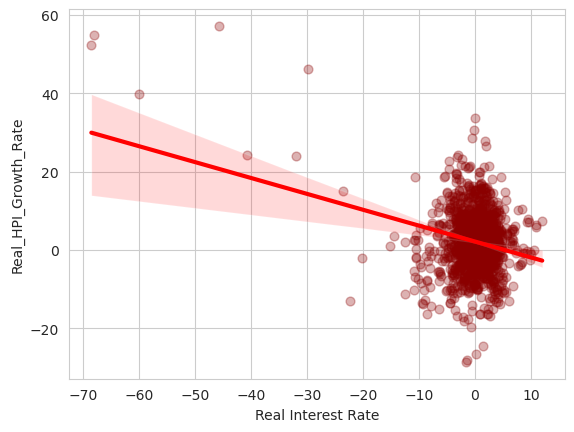

In [146]:
plot = sns.regplot(
    data=master_table, # from where
    x='Real Interest Rate', # x-axis name
    y='Real_HPI_Growth_Rate', # y-axis name
    scatter_kws={'alpha':0.3, 'color': '#8B0000', 's': 40}, # Dark Red dots (love red)
    line_kws={'color': '#FF0000', 'lw': 3, 'label': f'Linear Regression (R = {r_value:.3f})'} # Bright Red line
)

In [142]:
print(f"Mathematical Result: R = {r_value:.3f}, p-value= {p_value:.2e}")
plt.show()

Mathematical Result: R = -0.252, p-value= 6.41e-30
